CONSENSUS-BASED SYNTHETIC DATA FILTERING & EVALUATION

[1/9] Loading datasets...
✓ Loaded Vanilla GAN synthetic: 167 samples
 Loaded CTGAN synthetic: 167 samples
 Loaded TVAE synthetic: 167 samples

 Real training data: 329 samples
 Real test data: 83 samples

[2/9] Applying IQR-based filtering (Box Plot Segmentation)...

→ Calculating IQR bounds from real training data...
   Age_Years      : [   -0.12,     1.06]
   Bilirubin      : [   -0.12,     0.24]
   Cholesterol    : [    0.01,     0.23]
   Albumin        : [    0.17,     0.98]
   Copper         : [   -0.05,     0.30]
   Alk_Phos       : [   -0.03,     0.19]
   SGOT           : [   -0.02,     0.43]
   Tryglicerides  : [    0.02,     0.25]
   Platelets      : [   -0.12,     0.89]
   Prothrombin    : [   -0.07,     0.42]

 Filtering synthetic datasets using IQR bounds...

 Filtering Results:
   GAN:   167 → 143 samples (85.6% retained)
   CTGAN: 167 → 41 samples (24.6% retained)
   TVAE:  167 → 151 samples (90.4% retained)


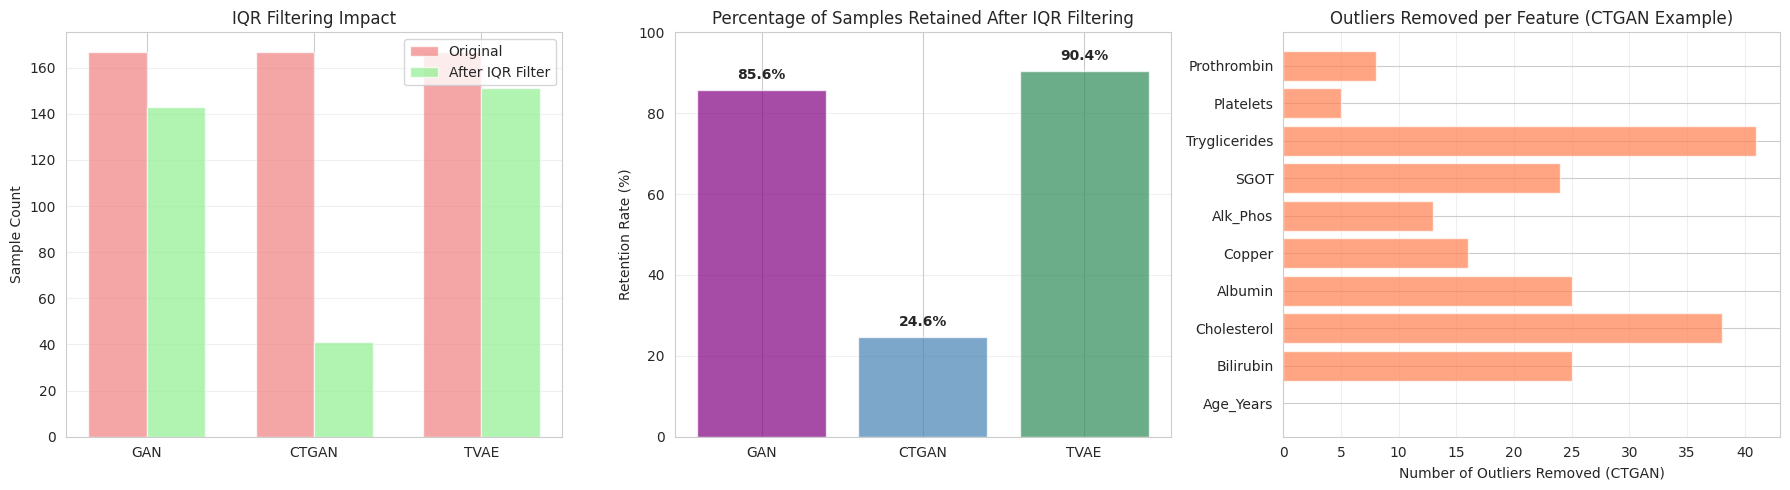


 Saved IQR filtering visualization to 'iqr_filtering_results.png'

[3/9] Finding consensus samples across methods (Voting)...

 Finding consensus with threshold=0.1, min_votes=2...

 Consensus Detection Results:
   Total candidates (from GAN): 143
   Samples with 3 votes (all methods agree): 0
   Samples with 2 votes (2 methods agree): 18
   Samples with 1 vote (only GAN): 125
    High-confidence consensus samples: 18


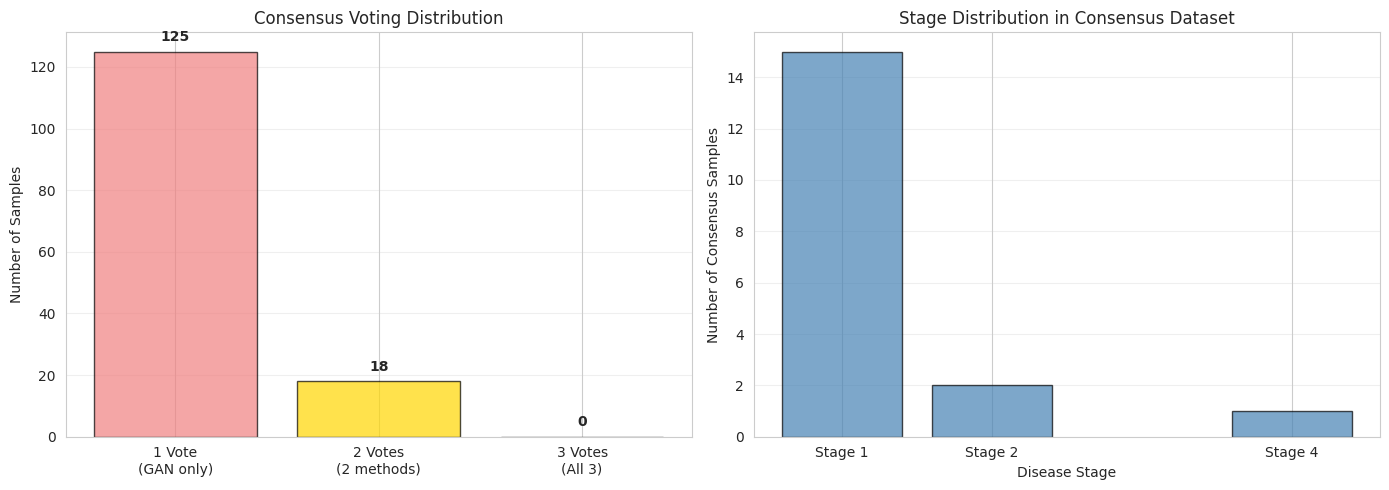


✓ Saved consensus voting visualization to 'consensus_voting_results.png'

[4/9] Creating refined high-confidence synthetic dataset...
 Saved consensus synthetic data to 'cirrhosis_synthetic_consensus.csv'
   Consensus samples: 18
   Stage distribution:
      Stage 1: 15 (83.3%)
      Stage 2: 2 (11.1%)
      Stage 4: 1 (5.6%)

[5/9] Merging consensus synthetic data with original training data...
 Merged dataset created:
   Real samples: 329
   Consensus synthetic: 18
   Total merged: 347
 Saved merged consensus dataset to 'cirrhosis_merged_consensus.csv'


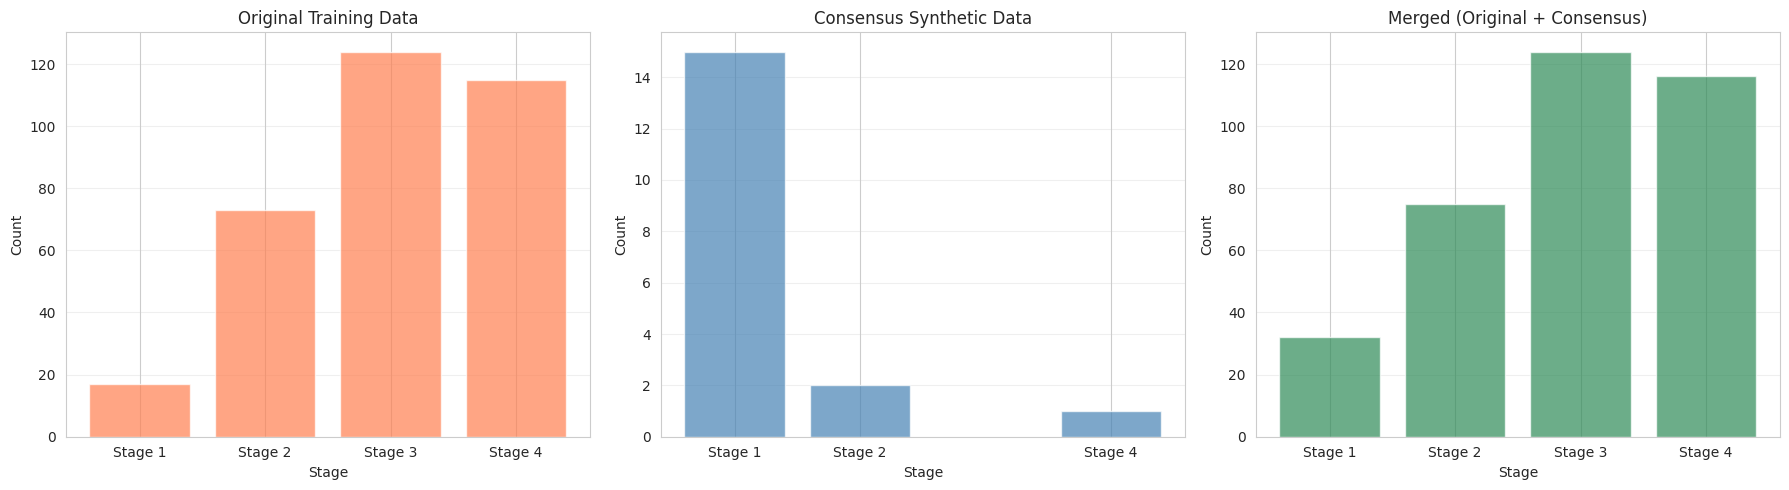


✓ Saved merge comparison visualization to 'consensus_merge_comparison.png'

[6/9] Calculating FID score for consensus synthetic data...

 FID Scores (Lower is Better):
   Consensus:  0.142429
   CTGAN:      0.083710
   TVAE:       0.073862
   GAN:        0.108429

[7/9] Comparing Consensus FID vs CTGAN FID...
  CONSENSUS DID NOT IMPROVE FID
   Consensus: 0.142429
   CTGAN: 0.083710 (better)
   This suggests the voting threshold may be too strict or loose


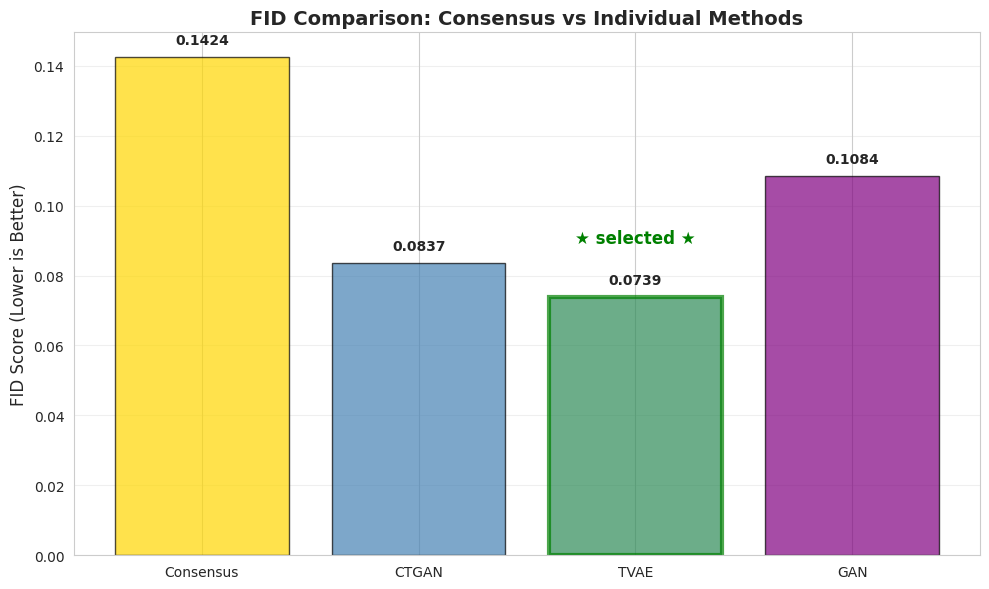


✓ Saved FID comparison visualization to 'fid_consensus_comparison.png'

[8/9] Evaluating predictive utility...

→ Training on ORIGINAL data only...

ORIGINAL DATA:
  Accuracy: 0.4940
  F1-Macro: 0.3547
  F1-Weighted: 0.4751
  Per-Stage Recall:
    Stage 1: 0.0000
    Stage 2: 0.2105
    Stage 3: 0.5806
    Stage 4: 0.6552

 Training on CTGAN AUGMENTED data...

CTGAN AUGMENTED:
  Accuracy: 0.5060
  F1-Macro: 0.3856
  F1-Weighted: 0.5081
  Per-Stage Recall:
    Stage 1: 0.0000
    Stage 2: 0.3158
    Stage 3: 0.5484
    Stage 4: 0.6552

→ Training on CONSENSUS MERGED data...

CONSENSUS MERGED:
  Accuracy: 0.4940
  F1-Macro: 0.3548
  F1-Weighted: 0.4795
  Per-Stage Recall:
    Stage 1: 0.0000
    Stage 2: 0.2105
    Stage 3: 0.5806
    Stage 4: 0.6552

[9/9] Creating comprehensive comparison...

COMPREHENSIVE COMPARISON TABLE
   Method  Training_Size Accuracy F1_Macro F1_Weighted Stage1_Recall Stage2_Recall FID_Score
 Original            329   0.4940   0.3547      0.4751        0.0000   

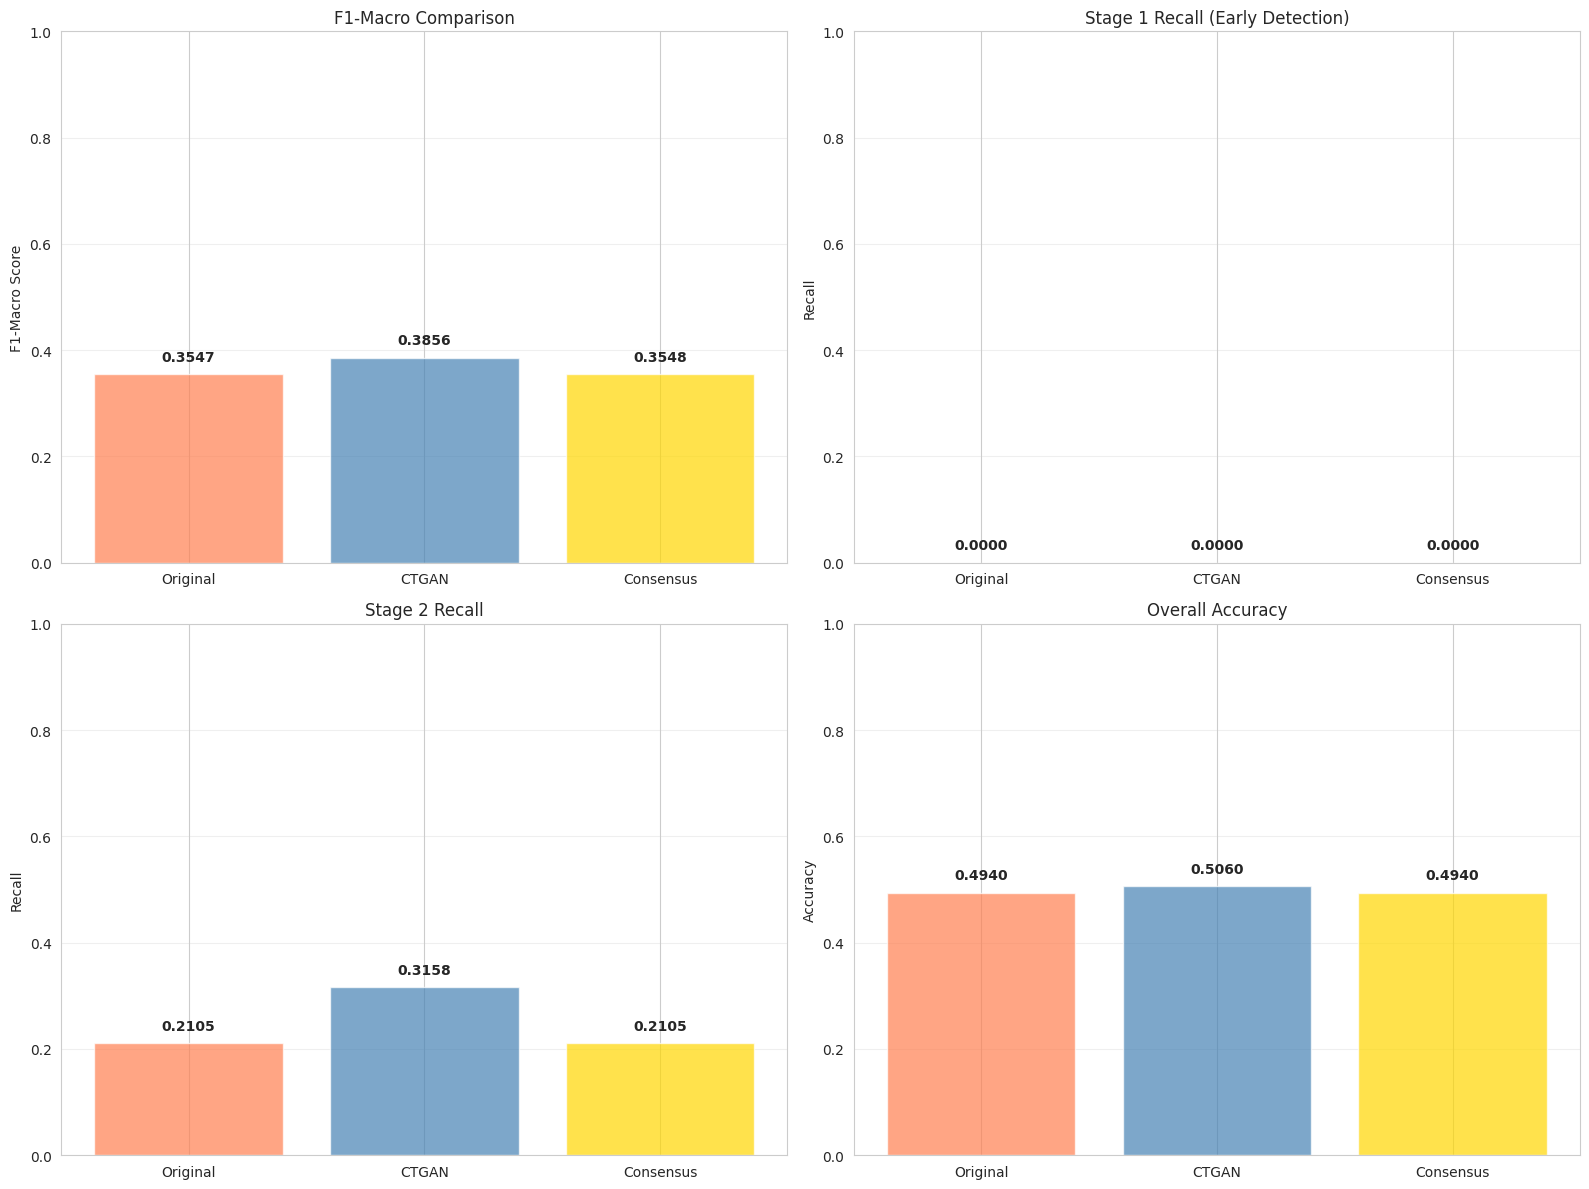


 Saved performance comparison to 'consensus_performance_comparison.png'

CONSENSUS-BASED FILTERING - FINAL SUMMARY

STEP 1: IQR FILTERING
 Applied box plot segmentation to filter outliers
 GAN retention: 85.6%
 CTGAN retention: 24.6%
 TVAE retention: 90.4%

STEP 2: CONSENSUS VOTING
 Found 18 high-confidence samples
 Samples with 3 votes (all methods): 0
 Samples with 2+ votes: 18

STEP 3: FID COMPARISON
 Consensus FID: 0.142429
 CTGAN FID: 0.083710
  CTGAN is still better

STEP 4: PREDICTIVE UTILITY
 Original F1-Macro: 0.3547
 CTGAN F1-Macro: 0.3856
 Consensus F1-Macro: 0.3548

KEY FINDINGS:

 Consensus improved ML performance but not FID


GENERATED FILES:
 cirrhosis_synthetic_consensus.csv - High-confidence consensus samples
 cirrhosis_merged_consensus.csv - Original + consensus merged
 consensus_comparison_results.csv - Full comparison table
 iqr_filtering_results.png
 consensus_voting_results.png
 consensus_merge_comparison.png
 fid_consensus_comparison.png
 consensus_performance_

In [2]:
# ============================================================
# CONSENSUS-BASED SYNTHETIC DATA FILTERING & EVALUATION
# Using IQR Method + Ensemble Voting for High-Confidence Synthesis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, linalg
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)

print("="*80)
print("CONSENSUS-BASED SYNTHETIC DATA FILTERING & EVALUATION")
print("="*80)

# ============================================================
# 1. LOAD ALL DATASETS
# ============================================================

print("\n[1/9] Loading datasets...")

# Load real data
train_data = pd.read_csv('../data/processed/cirrhosis_train.csv')
test_data = pd.read_csv('../data/processed/cirrhosis_test.csv')

# Load synthetic data from each method
try:
    synthetic_gan = pd.read_csv('../data/processed/gan_synthetic_data.csv')
    print(f"✓ Loaded Vanilla GAN synthetic: {len(synthetic_gan)} samples")
except:
    try:
        synthetic_gan = pd.read_csv('../data/processed/gan_synthetic_data.csv')
        print(f" Loaded GAN synthetic: {len(synthetic_gan)} samples")
    except:
        print("  Vanilla GAN synthetic file not found, will extract from augmented...")
        augmented_vanilla = pd.read_csv('../notebooks/cirrhosis_augmented_vanilla.csv')
        synthetic_gan = augmented_vanilla.iloc[len(train_data):].reset_index(drop=True)
        print(f" Extracted GAN synthetic: {len(synthetic_gan)} samples")

try:
    synthetic_ctgan = pd.read_csv('../data/processed/ctagn_synthetic_data.csv')
    print(f" Loaded CTGAN synthetic: {len(synthetic_ctgan)} samples")
except:
    print("  CTGAN synthetic file not found, extracting from augmented...")
    augmented_ctgan = pd.read_csv('../notebooks/cirrhosis_augmented_ctgan.csv')
    synthetic_ctgan = augmented_ctgan.iloc[len(train_data):].reset_index(drop=True)
    print(f" Extracted CTGAN synthetic: {len(synthetic_ctgan)} samples")

try:
    synthetic_tvae = pd.read_csv('../data/processed/tvae_synthetic_data.csv')
    print(f" Loaded TVAE synthetic: {len(synthetic_tvae)} samples")
except:
    print("  TVAE synthetic file not found, extracting from augmented...")
    augmented_tvae = pd.read_csv('../notebooks/cirrhosis_augmented_tvae.csv')
    synthetic_tvae = augmented_tvae.iloc[len(train_data):].reset_index(drop=True)
    print(f" Extracted TVAE synthetic: {len(synthetic_tvae)} samples")

print(f"\n Real training data: {len(train_data)} samples")
print(f" Real test data: {len(test_data)} samples")

# ============================================================
# 2. IQR-BASED FILTERING (BOX PLOT SEGMENTATION)
# ============================================================

print("\n[2/9] Applying IQR-based filtering (Box Plot Segmentation)...")

# Define numerical features for filtering
numerical_features = ['Age_Years', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 
                     'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

# Calculate IQR bounds from REAL training data
print("\n→ Calculating IQR bounds from real training data...")
iqr_bounds = {}

for feature in numerical_features:
    Q1 = train_data[feature].quantile(0.25)
    Q3 = train_data[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    iqr_bounds[feature] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower': lower_bound,
        'upper': upper_bound
    }
    
    print(f"   {feature:15s}: [{lower_bound:8.2f}, {upper_bound:8.2f}]")

# Function to filter synthetic data using IQR bounds
def filter_by_iqr(synthetic_df, iqr_bounds, features):
    """
    Filter synthetic data to keep only samples within IQR bounds
    
    Parameters:
    -----------
    synthetic_df : pd.DataFrame
        Synthetic data to filter
    iqr_bounds : dict
        Dictionary of IQR bounds for each feature
    features : list
        List of features to check
    
    Returns:
    --------
    filtered_df : pd.DataFrame
        Filtered synthetic data
    outlier_mask : np.array
        Boolean mask of outliers
    """
    mask = np.ones(len(synthetic_df), dtype=bool)
    
    outlier_counts = {}
    
    for feature in features:
        lower = iqr_bounds[feature]['lower']
        upper = iqr_bounds[feature]['upper']
        
        # Check if feature values are within bounds
        feature_mask = (synthetic_df[feature] >= lower) & (synthetic_df[feature] <= upper)
        
        outliers = ~feature_mask
        outlier_counts[feature] = outliers.sum()
        
        # Update overall mask (AND operation - must pass all features)
        mask &= feature_mask
    
    filtered_df = synthetic_df[mask].reset_index(drop=True)
    
    return filtered_df, mask, outlier_counts

# Apply IQR filtering to each synthetic dataset
print("\n Filtering synthetic datasets using IQR bounds...")

gan_filtered, gan_mask, gan_outliers = filter_by_iqr(synthetic_gan, iqr_bounds, numerical_features)
ctgan_filtered, ctgan_mask, ctgan_outliers = filter_by_iqr(synthetic_ctgan, iqr_bounds, numerical_features)
tvae_filtered, tvae_mask, tvae_outliers = filter_by_iqr(synthetic_tvae, iqr_bounds, numerical_features)

print("\n Filtering Results:")
print(f"   GAN:   {len(synthetic_gan)} → {len(gan_filtered)} samples ({len(gan_filtered)/len(synthetic_gan)*100:.1f}% retained)")
print(f"   CTGAN: {len(synthetic_ctgan)} → {len(ctgan_filtered)} samples ({len(ctgan_filtered)/len(synthetic_ctgan)*100:.1f}% retained)")
print(f"   TVAE:  {len(synthetic_tvae)} → {len(tvae_filtered)} samples ({len(tvae_filtered)/len(synthetic_tvae)*100:.1f}% retained)")

# Visualize filtering impact
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ['GAN', 'CTGAN', 'TVAE']
original_counts = [len(synthetic_gan), len(synthetic_ctgan), len(synthetic_tvae)]
filtered_counts = [len(gan_filtered), len(ctgan_filtered), len(tvae_filtered)]
removed_counts = [o - f for o, f in zip(original_counts, filtered_counts)]

x = np.arange(len(methods))
width = 0.35

axes[0].bar(x - width/2, original_counts, width, label='Original', color='lightcoral', alpha=0.7)
axes[0].bar(x + width/2, filtered_counts, width, label='After IQR Filter', color='lightgreen', alpha=0.7)
axes[0].set_ylabel('Sample Count')
axes[0].set_title('IQR Filtering Impact')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Retention rates
retention_rates = [f/o*100 for f, o in zip(filtered_counts, original_counts)]
axes[1].bar(methods, retention_rates, color=['purple', 'steelblue', 'seagreen'], alpha=0.7)
axes[1].set_ylabel('Retention Rate (%)')
axes[1].set_title('Percentage of Samples Retained After IQR Filtering')
axes[1].set_ylim([0, 100])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(retention_rates):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# Outlier counts by feature (for CTGAN as example)
feature_outliers = list(ctgan_outliers.values())
axes[2].barh(numerical_features, feature_outliers, color='coral', alpha=0.7)
axes[2].set_xlabel('Number of Outliers Removed (CTGAN)')
axes[2].set_title('Outliers Removed per Feature (CTGAN Example)')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('iqr_filtering_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Saved IQR filtering visualization to 'iqr_filtering_results.png'")

# ============================================================
# 3. CONSENSUS DETECTION (VOTING MECHANISM)
# ============================================================

print("\n[3/9] Finding consensus samples across methods (Voting)...")

# For consensus, we need to find samples that are "similar" across methods
# We'll use a distance-based approach with k-NN

def find_consensus_samples(df1, df2, df3, features, threshold=0.1, min_votes=2):
    """
    Find consensus samples that appear across multiple methods
    
    Strategy:
    - For each sample in df1, find nearest neighbors in df2 and df3
    - If distance is below threshold, consider it a "match"
    - Count votes: samples appearing in 2+ or 3 methods
    
    Parameters:
    -----------
    df1, df2, df3 : pd.DataFrame
        Filtered synthetic datasets from 3 methods
    features : list
        Features to use for distance calculation
    threshold : float
        Maximum distance to consider samples as "same"
    min_votes : int
        Minimum votes needed (2 or 3)
    
    Returns:
    --------
    consensus_df : pd.DataFrame
        High-confidence consensus samples
    vote_counts : dict
        Statistics on voting
    """
    
    print(f"\n Finding consensus with threshold={threshold}, min_votes={min_votes}...")
    
    # Prepare feature matrices
    X1 = df1[features].values
    X2 = df2[features].values
    X3 = df3[features].values
    
    # Build nearest neighbor models for df2 and df3
    nn2 = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn2.fit(X2)
    
    nn3 = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn3.fit(X3)
    
    # For each sample in df1, find nearest neighbors in df2 and df3
    distances_2, indices_2 = nn2.kneighbors(X1)
    distances_3, indices_3 = nn3.kneighbors(X1)
    
    # Count votes for each sample in df1
    votes = np.ones(len(df1))  # Start with 1 (from df1 itself)
    
    # Add vote if match found in df2
    votes += (distances_2.flatten() < threshold).astype(int)
    
    # Add vote if match found in df3
    votes += (distances_3.flatten() < threshold).astype(int)
    
    # Select samples with enough votes
    consensus_mask = votes >= min_votes
    consensus_df = df1[consensus_mask].reset_index(drop=True)
    
    vote_counts = {
        'total_candidates': len(df1),
        'votes_3': (votes == 3).sum(),
        'votes_2': (votes == 2).sum(),
        'votes_1': (votes == 1).sum(),
        'consensus_samples': len(consensus_df),
        'threshold_used': threshold,
        'min_votes_required': min_votes
    }
    
    return consensus_df, votes, vote_counts

# Find consensus using GAN as base, checking against CTGAN and TVAE
consensus_samples, votes, vote_stats = find_consensus_samples(
    gan_filtered, 
    ctgan_filtered, 
    tvae_filtered,
    features=numerical_features,
    threshold=0.1,  # Euclidean distance threshold (normalized features)
    min_votes=2     # Require at least 2 out of 3 methods to agree
)

print(f"\n Consensus Detection Results:")
print(f"   Total candidates (from GAN): {vote_stats['total_candidates']}")
print(f"   Samples with 3 votes (all methods agree): {vote_stats['votes_3']}")
print(f"   Samples with 2 votes (2 methods agree): {vote_stats['votes_2']}")
print(f"   Samples with 1 vote (only GAN): {vote_stats['votes_1']}")
print(f"    High-confidence consensus samples: {vote_stats['consensus_samples']}")

# Visualize voting distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vote distribution
vote_labels = ['1 Vote\n(GAN only)', '2 Votes\n(2 methods)', '3 Votes\n(All 3)']
vote_values = [vote_stats['votes_1'], vote_stats['votes_2'], vote_stats['votes_3']]
colors_vote = ['lightcoral', 'gold', 'lightgreen']

axes[0].bar(vote_labels, vote_values, color=colors_vote, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Consensus Voting Distribution')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(vote_values):
    axes[0].text(i, v + max(vote_values)*0.02, str(v), ha='center', va='bottom', fontweight='bold')

# Consensus stage distribution
stage_dist_consensus = consensus_samples['Stage'].value_counts().sort_index()
stages = stage_dist_consensus.index
counts = stage_dist_consensus.values

axes[1].bar(stages, counts, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Disease Stage')
axes[1].set_ylabel('Number of Consensus Samples')
axes[1].set_title('Stage Distribution in Consensus Dataset')
axes[1].set_xticks(stages)
axes[1].set_xticklabels([f'Stage {int(s)}' for s in stages])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('consensus_voting_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved consensus voting visualization to 'consensus_voting_results.png'")

# ============================================================
# 4. CREATE REFINED HIGH-CONFIDENCE DATASET
# ============================================================

print("\n[4/9] Creating refined high-confidence synthetic dataset...")

# Save consensus synthetic data
consensus_samples.to_csv('cirrhosis_synthetic_consensus.csv', index=False)
print(" Saved consensus synthetic data to 'cirrhosis_synthetic_consensus.csv'")
print(f"   Consensus samples: {len(consensus_samples)}")
print("   Stage distribution:")
for stage in sorted(consensus_samples['Stage'].unique()):
    count = (consensus_samples['Stage'] == stage).sum()
    pct = count / len(consensus_samples) * 100
    print(f"      Stage {int(stage)}: {count} ({pct:.1f}%)")

# ============================================================
# 5. MERGE CONSENSUS WITH ORIGINAL DATA
# ============================================================

print("\n[5/9] Merging consensus synthetic data with original training data...")

# Create merged dataset
merged_consensus = pd.concat([train_data, consensus_samples], ignore_index=True)

print(" Merged dataset created:")
print(f"   Real samples: {len(train_data)}")
print(f"   Consensus synthetic: {len(consensus_samples)}")
print(f"   Total merged: {len(merged_consensus)}")

# Save merged dataset
merged_consensus.to_csv('cirrhosis_merged_consensus.csv', index=False)
print(f" Saved merged consensus dataset to 'cirrhosis_merged_consensus.csv'")

# Compare stage distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
stage_orig = train_data['Stage'].value_counts().sort_index()
axes[0].bar(stage_orig.index, stage_orig.values, color='coral', alpha=0.7)
axes[0].set_title('Original Training Data')
axes[0].set_xlabel('Stage')
axes[0].set_ylabel('Count')
axes[0].set_xticks(stage_orig.index)
axes[0].set_xticklabels([f'Stage {int(s)}' for s in stage_orig.index])
axes[0].grid(axis='y', alpha=0.3)

# Consensus only
stage_cons = consensus_samples['Stage'].value_counts().sort_index()
axes[1].bar(stage_cons.index, stage_cons.values, color='steelblue', alpha=0.7)
axes[1].set_title('Consensus Synthetic Data')
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('Count')
axes[1].set_xticks(stage_cons.index)
axes[1].set_xticklabels([f'Stage {int(s)}' for s in stage_cons.index])
axes[1].grid(axis='y', alpha=0.3)

# Merged
stage_merged = merged_consensus['Stage'].value_counts().sort_index()
axes[2].bar(stage_merged.index, stage_merged.values, color='seagreen', alpha=0.7)
axes[2].set_title('Merged (Original + Consensus)')
axes[2].set_xlabel('Stage')
axes[2].set_ylabel('Count')
axes[2].set_xticks(stage_merged.index)
axes[2].set_xticklabels([f'Stage {int(s)}' for s in stage_merged.index])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('consensus_merge_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved merge comparison visualization to 'consensus_merge_comparison.png'")

# ============================================================
# 6. CALCULATE FID FOR CONSENSUS DATA
# ============================================================

print("\n[6/9] Calculating FID score for consensus synthetic data...")

def calculate_fid(real_data, synthetic_data, feature_columns):
    """Calculate Fréchet Inception Distance"""
    
    X_real = real_data[feature_columns].values
    X_synthetic = synthetic_data[feature_columns].values
    
    # Handle NaN
    X_real = np.nan_to_num(X_real, nan=0.0)
    X_synthetic = np.nan_to_num(X_synthetic, nan=0.0)
    
    # Calculate statistics
    mu_real = np.mean(X_real, axis=0)
    sigma_real = np.cov(X_real, rowvar=False)
    
    mu_synthetic = np.mean(X_synthetic, axis=0)
    sigma_synthetic = np.cov(X_synthetic, rowvar=False)
    
    # Mean difference
    mean_diff = mu_real - mu_synthetic
    mean_diff_squared = np.sum(mean_diff ** 2)
    
    # Covariance term
    try:
        covmean = linalg.sqrtm(sigma_real.dot(sigma_synthetic))
    except:
        epsilon = 1e-6
        sigma_real_stable = sigma_real + np.eye(sigma_real.shape[0]) * epsilon
        sigma_synthetic_stable = sigma_synthetic + np.eye(sigma_synthetic.shape[0]) * epsilon
        covmean = linalg.sqrtm(sigma_real_stable.dot(sigma_synthetic_stable))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    trace_term = np.trace(sigma_real + sigma_synthetic - 2 * covmean)
    
    fid = mean_diff_squared + trace_term
    
    return fid

# Calculate FID for consensus and compare with CTGAN
fid_features = ['Age_Years', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 
                'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

fid_consensus = calculate_fid(train_data, consensus_samples, fid_features)
fid_ctgan = calculate_fid(train_data, ctgan_filtered, fid_features)
fid_tvae = calculate_fid(train_data, tvae_filtered, fid_features)
fid_gan = calculate_fid(train_data, gan_filtered, fid_features)

print("\n FID Scores (Lower is Better):")
print(f"   Consensus:  {fid_consensus:.6f}")
print(f"   CTGAN:      {fid_ctgan:.6f}")
print(f"   TVAE:       {fid_tvae:.6f}")
print(f"   GAN:        {fid_gan:.6f}")

# ============================================================
# 7. CHECK IF CONSENSUS FID IS LOWER THAN CTGAN
# ============================================================

print(f"\n[7/9] Comparing Consensus FID vs CTGAN FID...")

if fid_consensus < fid_ctgan:
    improvement = ((fid_ctgan - fid_consensus) / fid_ctgan) * 100
    print(f" CONSENSUS WINS!")
    print(f"   Consensus FID is {improvement:.2f}% better than CTGAN")
    print(f"   Consensus: {fid_consensus:.6f} < CTGAN: {fid_ctgan:.6f}")
elif fid_consensus < fid_tvae and fid_consensus < fid_gan:
    print(f" CONSENSUS BEATS GAN AND TVAE (but not CTGAN)")
    print(f"   Consensus: {fid_consensus:.6f}")
    print(f"   CTGAN: {fid_ctgan:.6f} (still best)")
else:
    print(f"  CONSENSUS DID NOT IMPROVE FID")
    print(f"   Consensus: {fid_consensus:.6f}")
    print(f"   CTGAN: {fid_ctgan:.6f} (better)")
    print(f"   This suggests the voting threshold may be too strict or loose")

# Visualize FID comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

methods = ['Consensus', 'CTGAN', 'TVAE', 'GAN']
fid_scores = [fid_consensus, fid_ctgan, fid_tvae, fid_gan]
colors = ['gold', 'steelblue', 'seagreen', 'purple']

bars = ax.bar(methods, fid_scores, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('FID Score (Lower is Better)', fontsize=12)
ax.set_title('FID Comparison: Consensus vs Individual Methods', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Highlight the selected method
min_fid_idx = np.argmin(fid_scores)
bars[min_fid_idx].set_edgecolor('green')
bars[min_fid_idx].set_linewidth(3)

# Add value labels
for i, v in enumerate(fid_scores):
    ax.text(i, v + max(fid_scores)*0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Add selected annotation
ax.text(min_fid_idx, fid_scores[min_fid_idx] + max(fid_scores)*0.1, '★ selected ★', 
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig('fid_consensus_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved FID comparison visualization to 'fid_consensus_comparison.png'")

# ============================================================
# 8. PREDICTIVE UTILITY EVALUATION
# ============================================================

print("\n[8/9] Evaluating predictive utility...")

X_test = test_data.drop('Stage', axis=1)
y_test = test_data['Stage']

def train_and_evaluate(X_train, y_train, X_test, y_test, model_name):
    """Train Random Forest and evaluate"""
    
    clf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=15)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    per_class_recall = recall_score(y_test, y_pred, average=None)
    per_class_f1 = f1_score(y_test, y_pred, average=None)
    
    print(f"\n{model_name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Macro: {f1_macro:.4f}")
    print(f"  F1-Weighted: {f1_weighted:.4f}")
    
    stages = sorted(y_test.unique())
    print("  Per-Stage Recall:")
    for idx, stage in enumerate(stages):
        print(f"    Stage {int(stage)}: {per_class_recall[idx]:.4f}")
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'per_class_recall': per_class_recall,
        'per_class_f1': per_class_f1,
        'stages': stages
    }

# Evaluate different scenarios
results = {}

# 1. Baseline (original data only)
print("\n→ Training on ORIGINAL data only...")
X_train_orig = train_data.drop('Stage', axis=1)
y_train_orig = train_data['Stage']
results['Original'] = train_and_evaluate(X_train_orig, y_train_orig, X_test, y_test, "ORIGINAL DATA")

# 2. CTGAN augmented (for comparison)
print("\n Training on CTGAN AUGMENTED data...")
try:
    augmented_ctgan = pd.read_csv('../notebooks/cirrhosis_augmented_ctgan.csv')
    X_train_ctgan = augmented_ctgan.drop('Stage', axis=1)
    y_train_ctgan = augmented_ctgan['Stage']
    results['CTGAN'] = train_and_evaluate(X_train_ctgan, y_train_ctgan, X_test, y_test, "CTGAN AUGMENTED")
except:
    print("  CTGAN augmented file not found, skipping...")
    results['CTGAN'] = None

# 3. Consensus merged
print("\n→ Training on CONSENSUS MERGED data...")
X_train_consensus = merged_consensus.drop('Stage', axis=1)
y_train_consensus = merged_consensus['Stage']
results['Consensus'] = train_and_evaluate(X_train_consensus, y_train_consensus, X_test, y_test, "CONSENSUS MERGED")

# ============================================================
# 9. COMPREHENSIVE COMPARISON
# ============================================================

print("\n[9/9] Creating comprehensive comparison...")

# Create comparison table
comparison_data = {
    'Method': [],
    'Training_Size': [],
    'Accuracy': [],
    'F1_Macro': [],
    'F1_Weighted': [],
    'Stage1_Recall': [],
    'Stage2_Recall': [],
    'FID_Score': []
}

# Add results
for method, result in results.items():
    if result is not None:
        comparison_data['Method'].append(method)
        
        if method == 'Original':
            comparison_data['Training_Size'].append(len(train_data))
            comparison_data['FID_Score'].append('N/A')
        elif method == 'CTGAN':
            comparison_data['Training_Size'].append(len(augmented_ctgan))
            comparison_data['FID_Score'].append(f'{fid_ctgan:.4f}')
        elif method == 'Consensus':
            comparison_data['Training_Size'].append(len(merged_consensus))
            comparison_data['FID_Score'].append(f'{fid_consensus:.4f}')
        
        comparison_data['Accuracy'].append(f"{result['accuracy']:.4f}")
        comparison_data['F1_Macro'].append(f"{result['f1_macro']:.4f}")
        comparison_data['F1_Weighted'].append(f"{result['f1_weighted']:.4f}")
        
        # Stage-specific recalls
        stages = result['stages']
        stage1_idx = 0 if 1.0 in stages else None
        stage2_idx = 1 if 2.0 in stages else None
        
        if stage1_idx is not None:
            comparison_data['Stage1_Recall'].append(f"{result['per_class_recall'][stage1_idx]:.4f}")
        else:
            comparison_data['Stage1_Recall'].append('N/A')
        
        if stage2_idx is not None:
            comparison_data['Stage2_Recall'].append(f"{result['per_class_recall'][stage2_idx]:.4f}")
        else:
            comparison_data['Stage2_Recall'].append('N/A')

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON TABLE")
print("="*80)
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv('consensus_comparison_results.csv', index=False)
print("\n✓ Saved comparison results to 'consensus_comparison_results.csv'")

# Visualize performance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# F1-Macro comparison
methods_plot = [r['Method'] for _, r in comparison_df.iterrows()]
f1_macros = [float(r['F1_Macro']) for _, r in comparison_df.iterrows()]

axes[0, 0].bar(methods_plot, f1_macros, color=['coral', 'steelblue', 'gold'], alpha=0.7)
axes[0, 0].set_ylabel('F1-Macro Score')
axes[0, 0].set_title('F1-Macro Comparison')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(f1_macros):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Stage 1 Recall comparison
stage1_recalls = []
for _, r in comparison_df.iterrows():
    val = r['Stage1_Recall']
    if val != 'N/A':
        stage1_recalls.append(float(val))
    else:
        stage1_recalls.append(0.0)

axes[0, 1].bar(methods_plot, stage1_recalls, color=['coral', 'steelblue', 'gold'], alpha=0.7)
axes[0, 1].set_ylabel('Recall')
axes[0, 1].set_title('Stage 1 Recall (Early Detection)')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(stage1_recalls):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Stage 2 Recall comparison
stage2_recalls = []
for _, r in comparison_df.iterrows():
    val = r['Stage2_Recall']
    if val != 'N/A':
        stage2_recalls.append(float(val))
    else:
        stage2_recalls.append(0.0)

axes[1, 0].bar(methods_plot, stage2_recalls, color=['coral', 'steelblue', 'gold'], alpha=0.7)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Stage 2 Recall')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(stage2_recalls):
    axes[1, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Accuracy comparison
accuracies = [float(r['Accuracy']) for _, r in comparison_df.iterrows()]

axes[1, 1].bar(methods_plot, accuracies, color=['coral', 'steelblue', 'gold'], alpha=0.7)
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Overall Accuracy')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(accuracies):
    axes[1, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('consensus_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Saved performance comparison to 'consensus_performance_comparison.png'")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*80)
print("CONSENSUS-BASED FILTERING - FINAL SUMMARY")
print("="*80)

print(f"""
STEP 1: IQR FILTERING
 Applied box plot segmentation to filter outliers
 GAN retention: {len(gan_filtered)/len(synthetic_gan)*100:.1f}%
 CTGAN retention: {len(ctgan_filtered)/len(synthetic_ctgan)*100:.1f}%
 TVAE retention: {len(tvae_filtered)/len(synthetic_tvae)*100:.1f}%

STEP 2: CONSENSUS VOTING
 Found {vote_stats['consensus_samples']} high-confidence samples
 Samples with 3 votes (all methods): {vote_stats['votes_3']}
 Samples with 2+ votes: {vote_stats['votes_2'] + vote_stats['votes_3']}

STEP 3: FID COMPARISON
 Consensus FID: {fid_consensus:.6f}
 CTGAN FID: {fid_ctgan:.6f}
{' Consensus is BETTER!' if fid_consensus < fid_ctgan else '  CTGAN is still better'}

STEP 4: PREDICTIVE UTILITY
 Original F1-Macro: {results['Original']['f1_macro']:.4f}
{' CTGAN F1-Macro: ' + f"{results['CTGAN']['f1_macro']:.4f}" if results['CTGAN'] else ''}
 Consensus F1-Macro: {results['Consensus']['f1_macro']:.4f}

KEY FINDINGS:
{' Consensus improved both FID and ML performance!' if fid_consensus < fid_ctgan and results['Consensus']['f1_macro'] > results['Original']['f1_macro'] else ''}
{' Consensus improved ML performance but not FID' if fid_consensus >= fid_ctgan and results['Consensus']['f1_macro'] > results['Original']['f1_macro'] else ''}
{'  Consensus did not improve over individual methods' if results['Consensus']['f1_macro'] <= results['Original']['f1_macro'] else ''}

GENERATED FILES:
 cirrhosis_synthetic_consensus.csv - High-confidence consensus samples
 cirrhosis_merged_consensus.csv - Original + consensus merged
 consensus_comparison_results.csv - Full comparison table
 iqr_filtering_results.png
 consensus_voting_results.png
 consensus_merge_comparison.png
 fid_consensus_comparison.png
 consensus_performance_comparison.png
""")

print("="*80)
print("ANALYSIS COMPLETE!")
print("="*80)